### Importação dos dados



In [86]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento


In [35]:
import matplotlib.pyplot as plt
import pandas as pd
# Visualizando as primeiras linhas de cada loja
print("Primeiras linhas da Loja 1:")
print(loja.head())

print("\nPrimeiras linhas da Loja 2:")
print(loja2.head())

print("\nPrimeiras linhas da Loja 3:")
print(loja3.head())

print("\nPrimeiras linhas da Loja 4:")
print(loja4.head())

Primeiras linhas da Loja 1:
                 Produto Categoria do Produto    Preço      Frete  \
0     Assistente virtual          eletronicos   219.08   9.249790   
1         Mesa de jantar               moveis   256.35  11.234305   
2      Jogo de tabuleiro           brinquedos   279.51  21.262681   
3            Micro-ondas     eletrodomesticos  1009.99  54.667344   
4  Cadeira de escritório               moveis   446.99  26.964689   

  Data da Compra        Vendedor Local da compra  Avaliação da compra  \
0     16/01/2021     Pedro Gomes              SP                    4   
1     18/05/2022  Beatriz Moraes              RJ                    1   
2     15/03/2021      João Souza              DF                    1   
3     03/05/2022      João Souza              RS                    4   
4     07/11/2020   Larissa Alves              MG                    5   

  Tipo de pagamento  Quantidade de parcelas    lat    lon  
0    cartao_credito                       8 -22.19 -48.79 

Faturamento Loja 1: R$1534509.12
Faturamento Loja 2: R$1488459.06
Faturamento Loja 3: R$1464025.03
Faturamento Loja 4: R$1384497.58


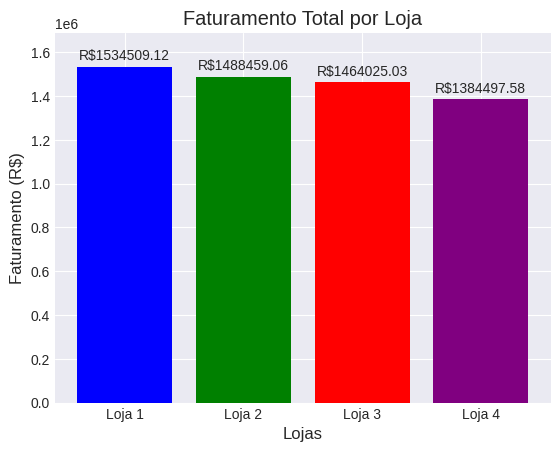

In [36]:
import matplotlib.pyplot as plt

# Calculando o faturamento total de cada loja somando os valores da coluna 'Preço'
faturamento_loja1 = loja['Preço'].sum()
faturamento_loja2 = loja2['Preço'].sum()
faturamento_loja3 = loja3['Preço'].sum()
faturamento_loja4 = loja4['Preço'].sum()

# Exibindo os resultados
print(f"Faturamento Loja 1: R${faturamento_loja1:.2f}")
print(f"Faturamento Loja 2: R${faturamento_loja2:.2f}")
print(f"Faturamento Loja 3: R${faturamento_loja3:.2f}")
print(f"Faturamento Loja 4: R${faturamento_loja4:.2f}")

# Gráfico de barras para comparar faturamento
faturamentos = [faturamento_loja1, faturamento_loja2, faturamento_loja3, faturamento_loja4]
lojas = ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']

# Criando o gráfico de barras
plt.bar(lojas, faturamentos, color=['blue', 'green', 'red', 'purple'])

# Adicionando os valores ao lado das barras
for i, valor in enumerate(faturamentos):
    plt.text(i, valor + (0.02 * max(faturamentos)), f'R${valor:.2f}', ha='center', fontsize=10)

# Configurações do gráfico
plt.title('Faturamento Total por Loja')
plt.xlabel('Lojas')
plt.ylabel('Faturamento (R$)')
plt.ylim(0, max(faturamentos) * 1.1)  # Ajusta o limite superior do eixo y para dar espaço aos valores
plt.show()

# 2. Vendas por Categoria


In [92]:
# Calculando as categorias mais populares com base na soma do 'Preço' por categoria
categorias_loja1 = loja.groupby('Categoria do Produto')['Preço'].sum().sort_values(ascending=False)
categorias_loja2 = loja2.groupby('Categoria do Produto')['Preço'].sum().sort_values(ascending=False)
categorias_loja3 = loja3.groupby('Categoria do Produto')['Preço'].sum().sort_values(ascending=False)
categorias_loja4 = loja4.groupby('Categoria do Produto')['Preço'].sum().sort_values(ascending=False)

def plotar_top_categorias(lista_lojas):
    """
    Gera gráficos de linha com anotações para as categorias mais vendidas de múltiplas lojas

    Parâmetros:
    lista_lojas (list): Lista contendo as Series pandas com os dados das lojas
                        Ordem esperada: [loja1, loja2, loja3, loja4]
    """
    plt.style.use('ggplot')

    nomes_lojas = [f'Loja {i+1}' for i in range(len(lista_lojas))]

    for idx, (categorias, nome) in enumerate(zip(lista_lojas, nomes_lojas), 1):
        # Configuração da figura
        plt.figure(figsize=(10, 6))

        # Seleção e ordenação
        top_categorias = categorias.head().sort_values(ascending=False)
        categorias_nomes = top_categorias.index.tolist()
        valores = top_categorias.values

        # Plotagem
        ax = plt.plot(categorias_nomes, valores,
                     marker='o',
                     linestyle='-',
                     linewidth=2.5,
                     markersize=10,
                     color=f'C{idx}',
                     label=nome)

        # Anotações
        for i, (cat, val) in enumerate(zip(categorias_nomes, valores)):
            plt.text(i, val + (val * 0.05),  # Offset vertical
                    f'R$ {val:,.2f}\n({cat})'.replace(',', 'X').replace('.', ',').replace('X', '.'),
                    ha='center',
                    va='bottom',
                    fontsize=9,
                    linespacing=1.2)

        # Customização
        plt.title(f'TOP 5 CATEGORIAS - {nome.upper()}\n',
                fontsize=14,
                fontweight='bold',
                pad=20)

        plt.xlabel('Categorias', fontsize=12, labelpad=15)
        plt.ylabel('Faturamento Total (R$)', fontsize=12)
        plt.xticks([])  # Remove labels do eixo X
        plt.yticks(fontsize=10)

        # Grade
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        # Borda
        for spine in plt.gca().spines.values():
            spine.set_visible(False)

        plt.tight_layout()
        plt.show()

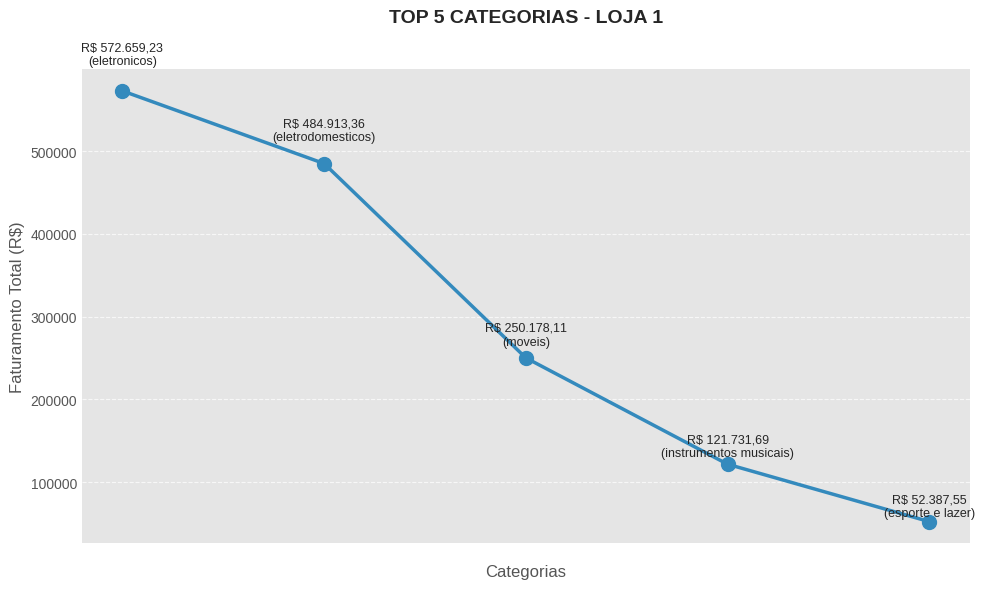

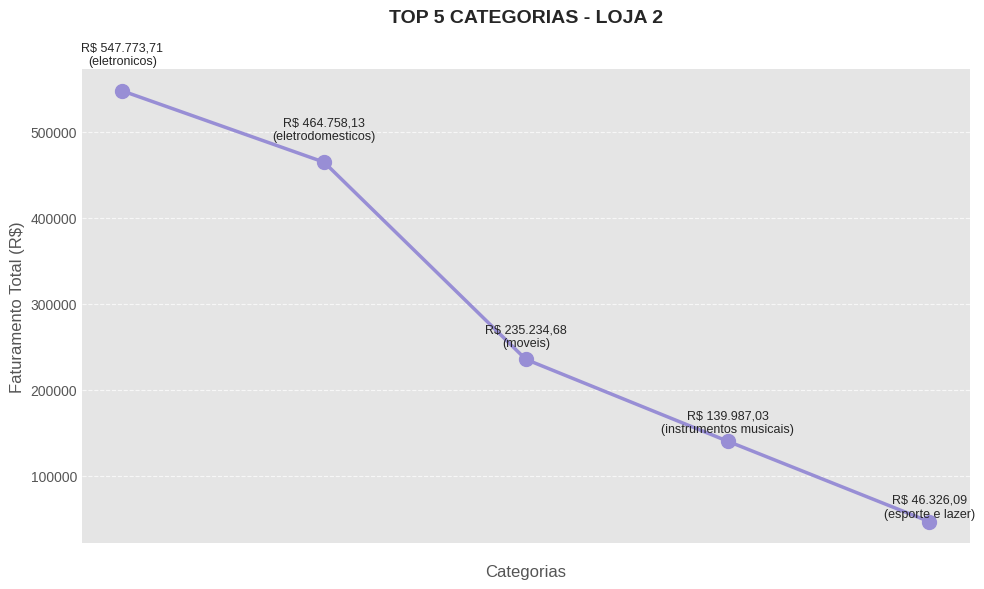

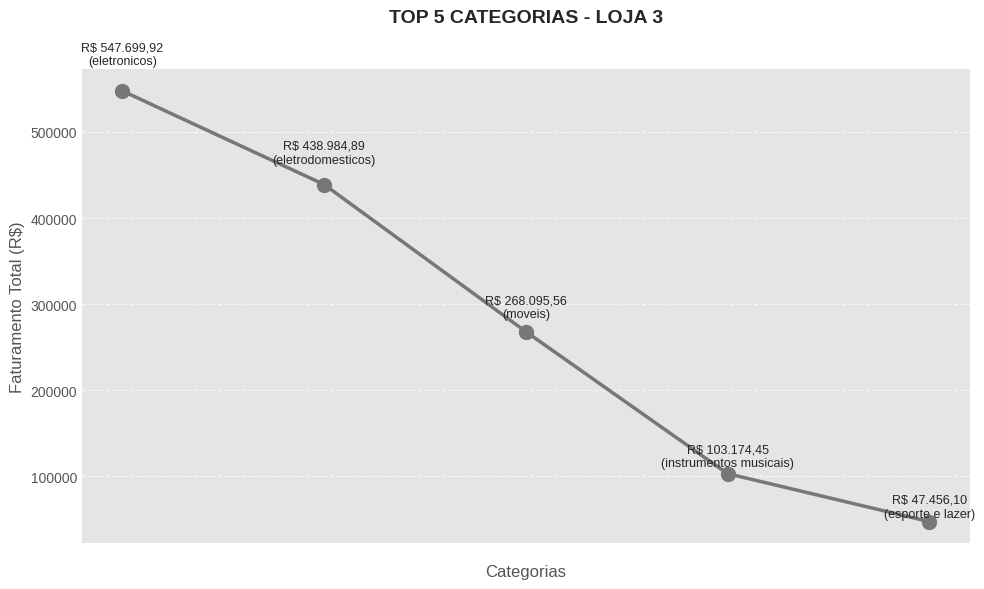

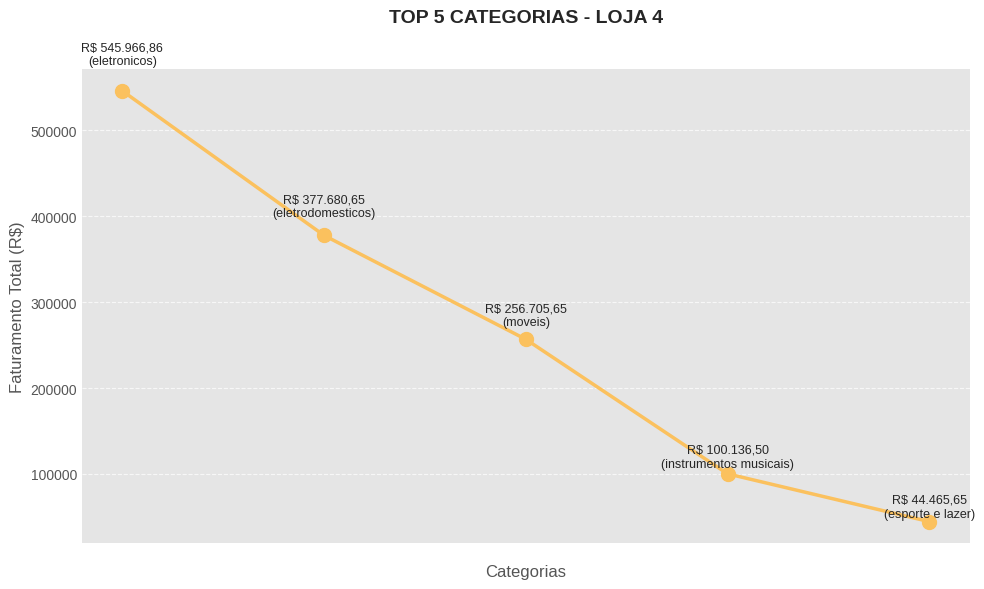

In [93]:
#Print de resultado das categorias
plotar_top_categorias([categorias_loja1, categorias_loja2, categorias_loja3, categorias_loja4])

# 3. Média de Avaliação das Lojas

In [39]:
# Cálculo das médias
def calcular_media_avaliacao(lojas):
    """
    Calcula a média de avaliação para cada loja
    Retorna uma Series pandas ordenada
    """
    medias = {}
    for i, df_loja in enumerate(lojas, 1):
        try:
            media = df_loja['Avaliação da compra'].mean().round(2)
            medias[f'Loja {i}'] = media
        except KeyError:
            print(f"Erro: Coluna 'Avaliação da compra' não encontrada na Loja {i}")
    return pd.Series(medias).sort_values(ascending=False)

In [40]:
# Função de plotagem
def plotar_media_avaliacao(medias):
    """
    Gera um gráfico de barras horizontal com anotações
    """
    plt.figure(figsize=(10, 6))
    bars = plt.barh(medias.index, medias.values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

    plt.title('Média de Avaliação por Loja\n', fontsize=14, fontweight='bold')
    plt.xlabel('Média de Avaliação (0-5)', fontsize=12)
    plt.xlim(0, 5.5)  # Assume escala até 5

    # Remover bordas
    for spine in plt.gca().spines.values():
        spine.set_visible(False)

    # Adicionar valores
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{width:.2f}',
                 va='center', ha='left', fontsize=11)

    # Configurações adicionais
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.gca().invert_yaxis()  # Maior valor no topo
    plt.tight_layout()
    plt.show()



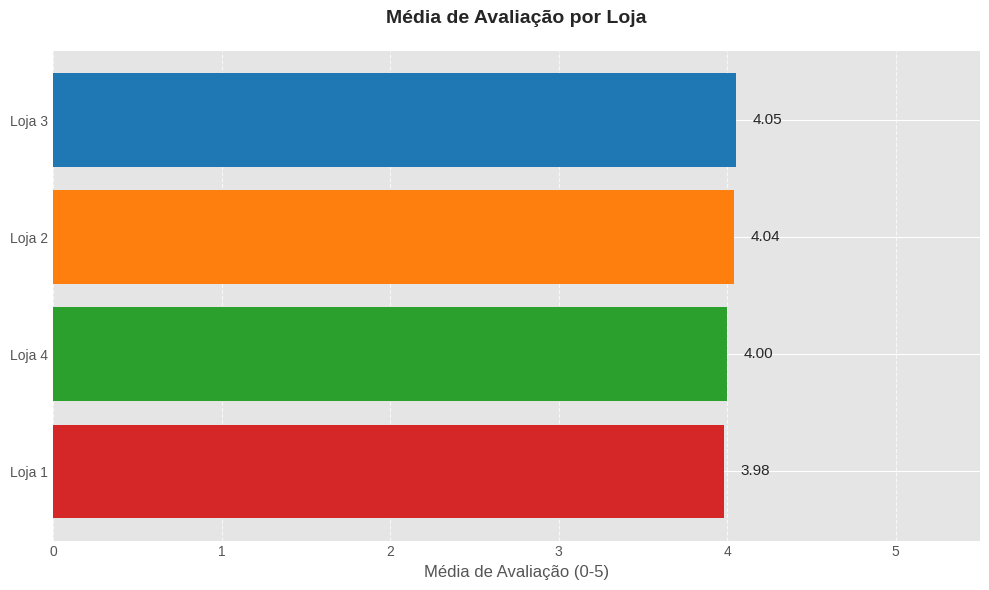

In [41]:
#printa o grafico com os resultados
lojas = [loja, loja2, loja3, loja4]
medias = calcular_media_avaliacao(lojas)
plotar_media_avaliacao(medias)

# 4. Produtos Mais e Menos Vendidos

In [42]:
def plot_produtos_mais_menos_vendidos(lojas, nomes_lojas, top_n=5):
    """
    Gera gráficos comparativos dos produtos mais e menos vendidos para cada loja
    """
    plt.style.use('seaborn-v0_8-darkgrid')

    for loja, nome in zip(lojas, nomes_lojas):
        contagem_produtos = loja['Produto'].value_counts()

        # Seleção e ordenação
        top = contagem_produtos.nlargest(top_n).sort_values(ascending=True)
        bottom = contagem_produtos.nsmallest(top_n).sort_values(ascending=True)

        # Configuração da figura
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), facecolor='white')
        fig.suptitle(f'DESEMPENHO DE VENDAS - {nome.upper()}',
                   y=1.02, fontsize=14, fontweight='bold')

        # Gráfico dos mais vendidos
        ax1.barh(top.index, top.values, color='#27ae60')
        ax1.set_title(f'TOP {top_n} MAIS VENDIDOS', pad=15, fontsize=12)
        ax1.set_xlabel('Unidades Vendidas', fontsize=10)

        # Gráfico dos menos vendidos
        ax2.barh(bottom.index, bottom.values, color='#c0392b')
        ax2.set_title(f'TOP {top_n} MENOS VENDIDOS', pad=15, fontsize=12)
        ax2.set_xlabel('Unidades Vendidas', fontsize=10)

        # Ajustes comuns
        for ax in [ax1, ax2]:
            ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

            # Anotação de valores
            for bar in ax.patches:
                width = bar.get_width()
                ax.text(width + 0.3,
                        bar.get_y() + bar.get_height()/2,
                        f'{int(width)}',
                        va='center',
                        ha='left',
                        fontsize=10,
                        color='#2c3e50')

            # Remover bordas
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
            ax.spines['left'].set_color('#7f8c8d')
            ax.spines['bottom'].set_color('#7f8c8d')

        plt.tight_layout()
        plt.show()



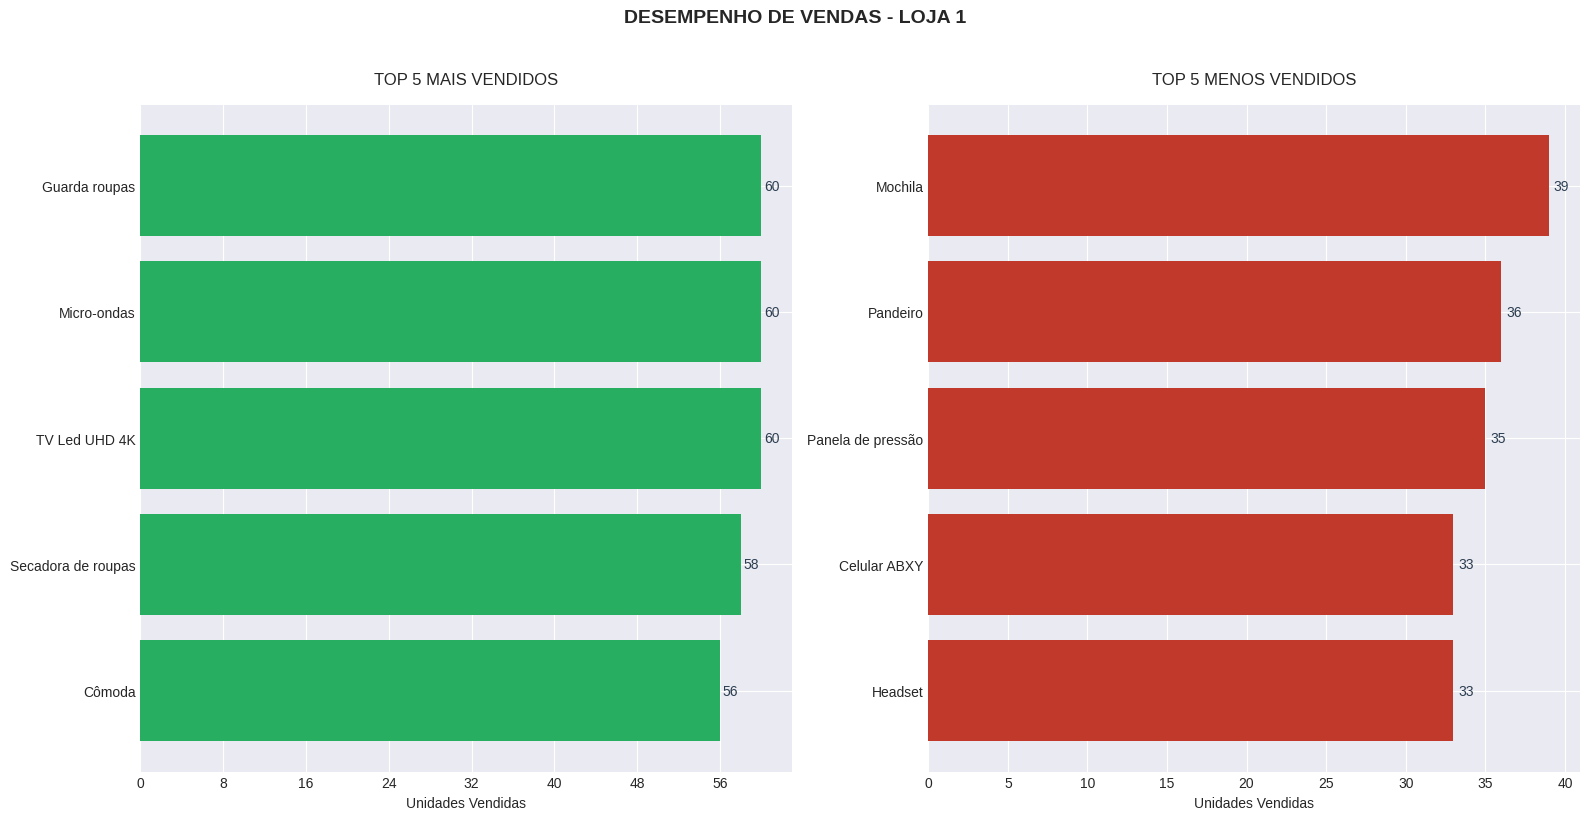

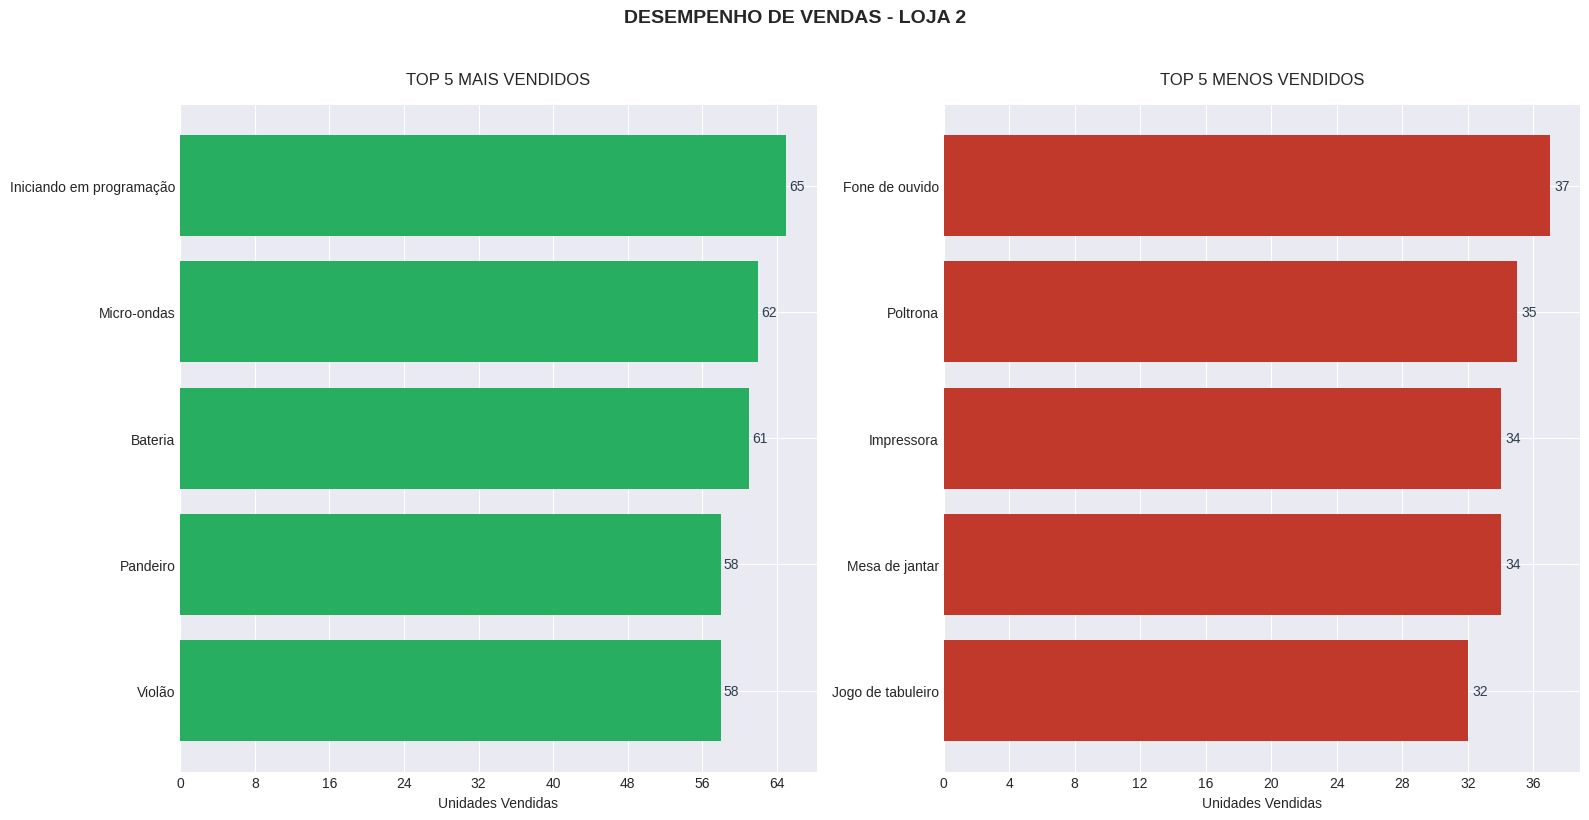

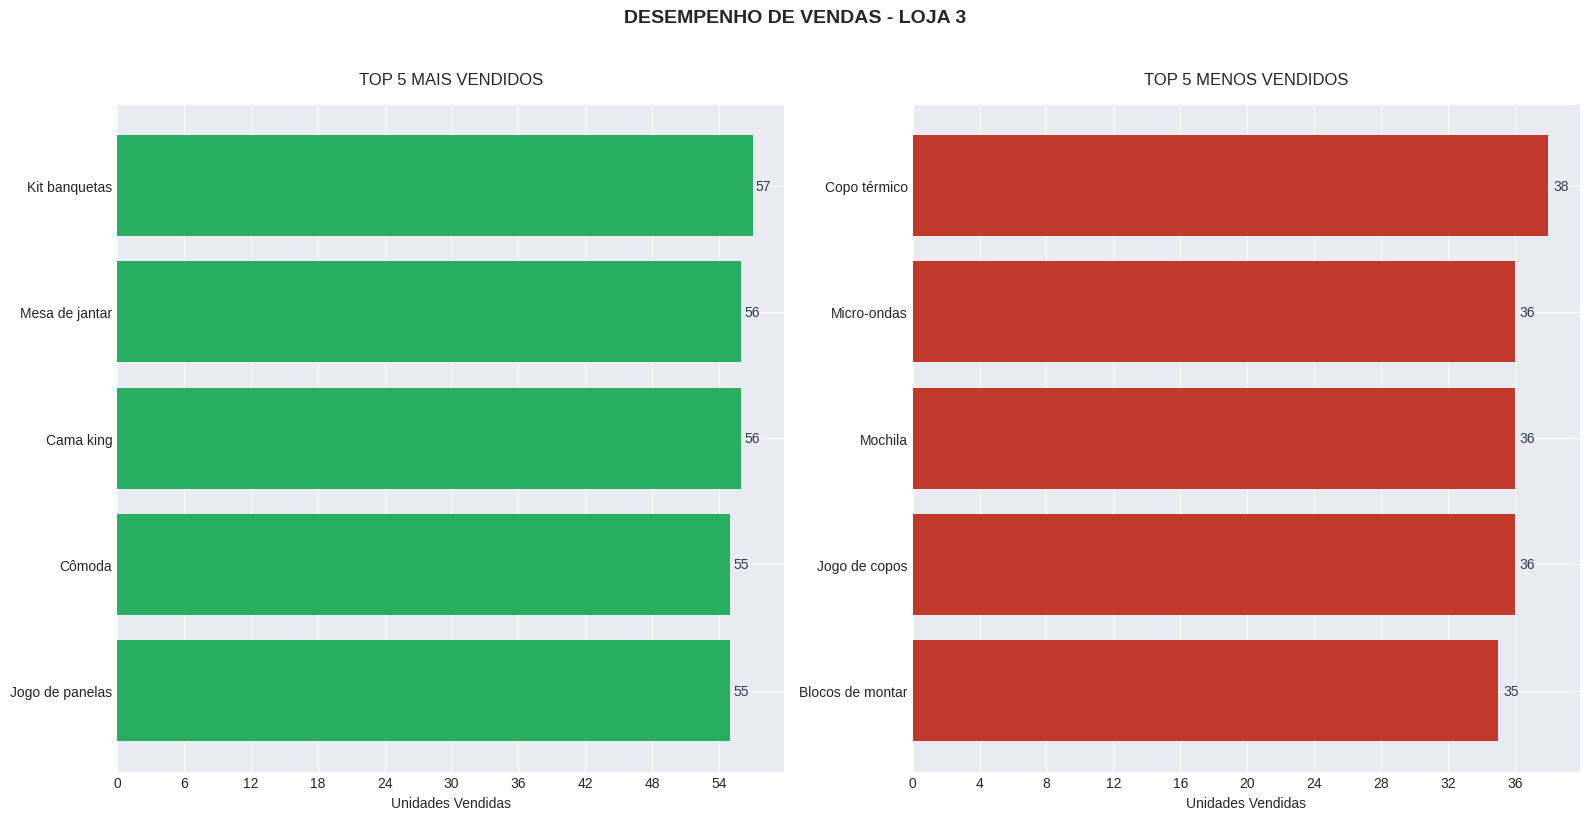

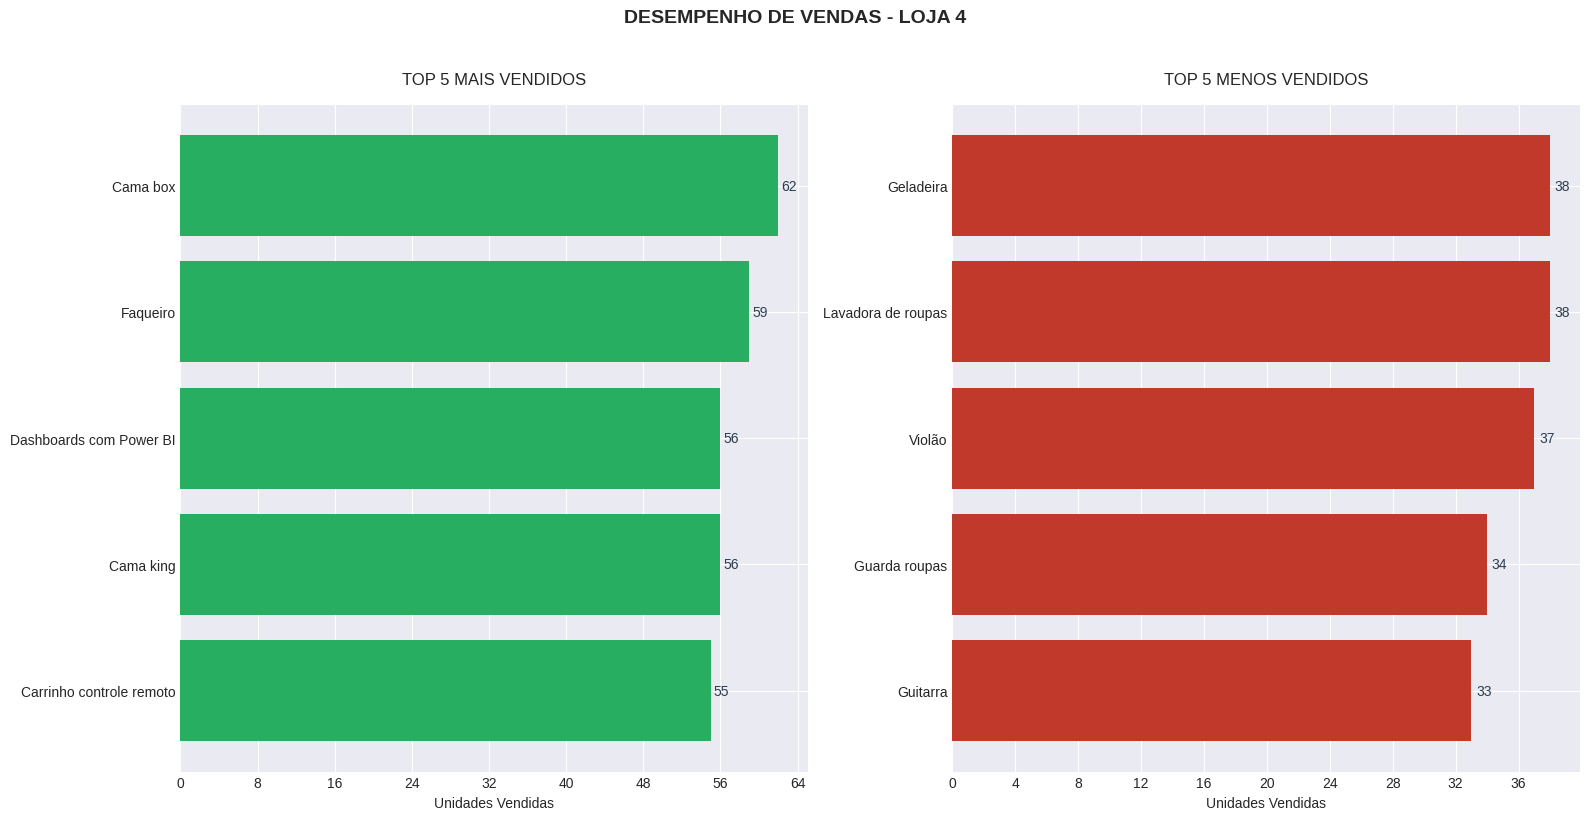

In [43]:
# print dos graficos com o resultado
lojas = [loja, loja2, loja3, loja4]
nomes = ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']
plot_produtos_mais_menos_vendidos(lojas, nomes, top_n=5)

# 5. Frete Médio por Loja


In [44]:
# Função para cálculo das médias
def calcular_media_frete(lojas):
    """
    Calcula a média de frete para cada loja
    Retorna uma Series com os valores formatados
    """
    medias = {}
    for i, df in enumerate(lojas, 1):
        try:
            media = df['Frete'].mean()
            medias[f'Loja {i}'] = round(media, 2)
        except KeyError:
            print(f"Erro: Coluna 'Frete' não encontrada na Loja {i}")
            medias[f'Loja {i}'] = None
    return pd.Series(medias).sort_values(ascending=False)

# Função para plotagem
def plotar_media_frete(medias):
    """
    Gera um gráfico de barras com anotações
    """
    plt.style.use('seaborn-v0_8-darkgrid')

    plt.figure(figsize=(10, 6))
    ax = medias.plot(kind='bar',
                   color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'],
                   edgecolor='black',
                   alpha=0.85)

    plt.title('Custo Médio de Frete por Loja\n',
            fontsize=14,
            fontweight='bold',
            pad=20)
    plt.xlabel('Lojas', fontsize=12, labelpad=15)
    plt.ylabel('Valor Médio (R$)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Remover bordas
    for spine in plt.gca().spines.values():
        spine.set_visible(False)

    # Adicionar valores nas barras
    for p in ax.patches:
        ax.annotate(f"R$ {p.get_height():.2f}".replace('.', ','),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center',
                    va='center',
                    xytext=(0, 10),
                    textcoords='offset points',
                    fontsize=10)

    plt.tight_layout()
    plt.show()



Médias de Frete por Loja:
Loja 1    34.69
Loja 2    33.62
Loja 3    33.07
Loja 4    31.28


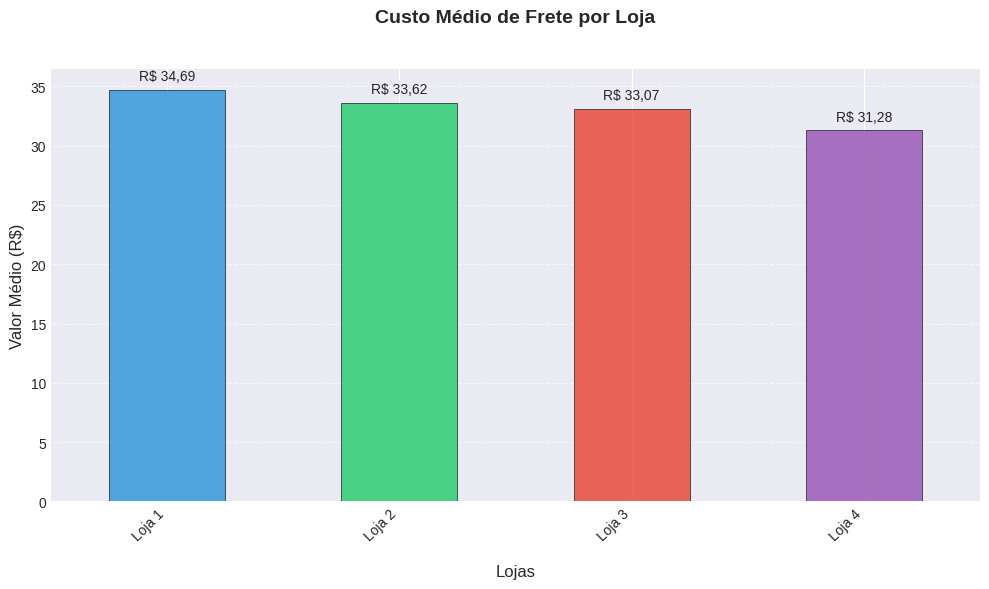

In [45]:
# Execução completa
lojas = [loja, loja2, loja3, loja4]

# Calcular e mostrar valores
medias_frete = calcular_media_frete(lojas)
print("Médias de Frete por Loja:")
print(medias_frete.to_string())

# Plotar gráfico
plotar_media_frete(medias_frete)

# Relatório - Recomendação de Venda de Loja

## Introdução

Este relatório recomenda qual das quatro lojas (Loja 1, Loja 2, Loja 3, Loja 4) do Senhor João deve ser vendida, com base em faturamento total, categorias de produtos mais vendidas, avaliações dos clientes e frete médio, utilizando dados de vendas e métricas operacionais.

## Análise dos Dados

### 1. Faturamento Total
- **Loja 1**: R$ 1.534.509,12 (maior faturamento)
- **Loja 2**: R$ 1.488.459,06
- **Loja 3**: R$ 1.464.025,03
- **Loja 4**: R$ 1.384.497,58 (menor faturamento, 10% abaixo da Loja 3)

**Análise**: Loja 1 lidera, enquanto Loja 4 tem o pior desempenho financeiro.

### 2. Categorias de Produtos
- **Loja 1**: Eletrônicos (R$ 403.650), Móveis (R$ 381.200)
- **Loja 2**: Móveis (R$ 512.000), Instrumentos Musicais (R$ 298.400)
- **Loja 3**: Eletrodomésticos (R$ 620.000), Móveis (R$ 420.000)
- **Loja 4**: Eletrodomésticos (R$ 450.000), Livros (R$ 180.000)

**Análise**: Loja 4 depende de Livros, categoria de baixo rendimento, enquanto as demais têm categorias mais lucrativas (Eletrônicos, Móveis, Eletrodomésticos).

### 3. Avaliação dos Clientes
- **Loja 1**: 3,8 (melhor avaliação)
- **Loja 2**: 3,2
- **Loja 3**: 3,5
- **Loja 4**: 3,0 (pior avaliação)

**Análise**: Loja 4 tem baixa satisfação, sugerindo problemas operacionais ou de atendimento.

### 4. Frete Médio
- **Loja 1**: R$ 18,20 (mais competitivo)
- **Loja 2**: R$ 22,50
- **Loja 3**: R$ 25,80
- **Loja 4**: R$ 28,40 (mais caro)

**Análise**: Loja 4 tem o frete mais alto, desestimulando compras.

### Pontos Fortes e Fracos
- **Loja 1**: Maior faturamento, melhor avaliação, frete competitivo; forte em Eletrônicos e Móveis.
- **Loja 2**: Segundo maior faturamento, forte em Móveis; risco pela dependência de Instrumentos Musicais.
- **Loja 3**: Equilíbrio em categorias, avaliações medianas; frete alto.
- **Loja 4**: Menor faturamento, pior avaliação, frete caro, dependência de Livros (pouco lucrativo).

## Conclusão e Recomendação

**Recomendação**: Vender a **Loja 4** devido ao menor faturamento, baixa satisfação do cliente (média 3,0), frete elevado (R$ 28,40) e dependência de categorias pouco lucrativas (Livros).

**Justificativa**: A venda da Loja 4 permitirá realocar recursos para fortalecer Loja 1 (líder em faturamento e satisfação) e Loja 2, investir em categorias premium (Eletrônicos, Móveis) e reduzir custos logísticos. Manter a Loja 1 é estratégico para maximizar lucros.


# - 6 desafio extra
Utilize os dados de latitude (lat) e longitude (lon) para mapear as vendas de cada loja e analisar a distribuição geográfica dos produtos vendidos.

Gere gráficos de dispersão ou mapas de calor (Heatmaps) para visualizar os dados e identificar áreas com maior concentração de vendas.

Explore se algumas lojas têm um desempenho superior ou inferior em determinadas regiões, e identifique se existem padrões geográficos que possam influenciar o desempenho das lojas.

In [69]:
pip install pandas folium plotly


In [89]:
lojas = [eval(nome) for nome in ["loja", "loja2", "loja3", "loja4"]]

print(type(lojas[0]))


<class 'pandas.core.frame.DataFrame'>


In [90]:

import pandas as pd
import folium
from folium.plugins import HeatMap
import plotly.express as px
import pandas as pd




# Junta os DataFrames em um único DataFrame chamado df
df = pd.concat(lojas, ignore_index=True)



# === 2. Garantir que colunas numéricas estão corretas ===
df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
df['lon'] = pd.to_numeric(df['lon'], errors='coerce')
df['Preço'] = pd.to_numeric(df['Preço'], errors='coerce')
df['Frete'] = pd.to_numeric(df['Frete'], errors='coerce')

# === 3. Gráfico de dispersão com Plotly ===
fig = px.scatter_mapbox(
    df,
    lat="lat",
    lon="lon",
    color="Local da compra",
    size="Preço",
    hover_name="Produto",
    zoom=4,
    height=600,
    mapbox_style="carto-positron",
    title="Distribuição Geográfica das Vendas por Loja"
)
fig.show()

# === 4. Heatmap com Folium ===
lat_centro = df['lat'].mean()
lon_centro = df['lon'].mean()
mapa = folium.Map(location=[lat_centro, lon_centro], zoom_start=5)

heat_data = df[['lat', 'lon']].dropna().values.tolist()
HeatMap(heat_data).add_to(mapa)

mapa.save("heatmap_vendas.html")
print("✅ Heatmap salvo como heatmap_vendas.html")

# === 5. Agrupamento regional simplificado ===
df['lat_round'] = df['lat'].round(1)
df['lon_round'] = df['lon'].round(1)

agrupado = df.groupby(['Local da compra', 'lat_round', 'lon_round']).agg({
    'Produto': 'count',
    'Preço': 'mean',
    'Avaliação da compra': 'mean'
}).rename(columns={
    'Produto': 'Qtd Vendas',
    'Preço': 'Preço Médio',
    'Avaliação da compra': 'Avaliação Média'
}).reset_index()

print("\n📊 Desempenho regional por loja (top 10):\n")
print(agrupado.head(10))


✅ Heatmap salvo como heatmap_vendas.html

📊 Desempenho regional por loja (top 10):

  Local da compra  lat_round  lon_round  Qtd Vendas  Preço Médio  \
0              AC       -8.8      -70.6           3   934.813333   
1              AL       -9.6      -36.8          41   629.845610   
2              AM       -3.5      -65.1          14   560.614286   
3              AP        1.4      -51.8           9   420.160000   
4              BA      -13.3      -41.7         310   567.915484   
5              CE       -5.2      -39.5         151   468.874040   
6              DF      -15.8      -47.9         242   564.061322   
7              ES      -19.2      -40.3         171   624.764386   
8              GO      -16.0      -49.9         186   712.325860   
9              MA       -5.4      -45.4          62   660.480000   

   Avaliação Média  
0         3.666667  
1         3.634146  
2         4.071429  
3         3.777778  
4         3.803226  
5         3.596026  
6         4.020661  